#### EDA (Exploratory Data Analysis)

1. Load datasets
2. Clean data (missing values,duplicates,types)
3. Treat outliers
4. Univariate and bivariate and multivariate analysis
5. insights

##### Outlier- a data point that is significantly different from other observations in a dataset.

How outliers will come---?
1. Measurement errors
2. Data entry mistakes

Why they are important---?
1. They can be errors
2. They effect the data analysis

How to identify the outliers....?
1. Statistical methods

---> Interquartile Range (IQR)

---> Z-Score

2. Visualization Techniques
---> Box Plots

---> Scatter Plots

---> Histograms


Univariate analysis--a method that analyzes a single variable to describe its characteristics and finding patterns and summarize the data.

It involves only one variable.
 
Bi variate analysis-it will give relationship between 2 variables.It helps to find if there is any co-relation ,association or connection between the 2 variables 

It involves 2 variables (x & y)

Multivariate analysis-To understand how multiple factors interact and influence with each other

It involves more than 2  

Example-

How our age,income,and education level together influence the purchasing behaviour.

### ETL

## EDA : <Dataset>

1. Load &overview

2. Cleaning (missing,dupes,dtypes)

3. Uni , Bi & multi analysis

4. Outlier -IQR

5. Feature Engineering 

6. Key Insights

Feature Engineering - " F.E is the process of turning raw data into useful features" that helps to improve the performance of machine learning models.

1. Load libraries and dataset

In [1]:
import pandas as pd
import numpy as numpy
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Load the sleep  and health dataset from seaborn 
df = pd.read_csv(r"C:\Users\Sriram reddy\Downloads\Sleep_health_and_lifestyle_dataset.csv")
df.head()
df.tail()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
373,374,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [3]:
#Basic information and overview of the dataset 
print("Shape of the dataset:",df.shape)
print("\n Info about the dataset ;\n")
df.info()
#Summary Statistics 
df.describe(include='all')

Shape of the dataset: (374, 13)

 Info about the dataset ;

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
count,374.000000,374,374.000000,374,374.000000,374.000000,374.000000,374.000000,374,374,374.000000,374.000000,155
unique,NaN,2,NaN,11,NaN,NaN,NaN,NaN,4,25,NaN,NaN,2
top,NaN,Male,NaN,Nurse,NaN,NaN,NaN,NaN,Normal,130/85,NaN,NaN,Sleep Apnea
freq,NaN,189,NaN,73,NaN,NaN,NaN,NaN,195,99,NaN,NaN,78
mean,187.500000,NaN,42.184492,NaN,7.132086,7.312834,59.171123,5.385027,NaN,NaN,70.165775,6816.844920,NaN
std,108.108742,NaN,8.673133,NaN,0.795657,1.196956,20.830804,1.774526,NaN,NaN,4.135676,1617.915679,NaN
min,1.000000,NaN,27.000000,NaN,5.800000,4.000000,30.000000,3.000000,NaN,NaN,65.000000,3000.000000,NaN
25%,94.250000,NaN,35.250000,NaN,6.400000,6.000000,45.000000,4.000000,NaN,NaN,68.000000,5600.000000,NaN
50%,187.500000,NaN,43.000000,NaN,7.200000,7.000000,60.000000,5.000000,NaN,NaN,70.000000,7000.000000,NaN
75%,280.750000,NaN,50.000000,NaN,7.800000,8.000000,75.000000,7.000000,NaN,NaN,72.000000,8000.000000,NaN


In [4]:
#Missing values analysis 

missing=pd.DataFrame({
    'missing_count':df.isnull().sum(),
    'missing_percent':(df.isnull().sum()/ len(df)) * 100
})

missing.sort_values(by='missing_percent',ascending=False)

,missing_count,missing_percent
Sleep Disorder,219,58.55615
Gender,0,0.00000
Age,0,0.00000
Occupation,0,0.00000
Person ID,0,0.00000
Sleep Duration,0,0.00000
Quality of Sleep,0,0.00000
Stress Level,0,0.00000
Physical Activity Level,0,0.00000
BMI Category,0,0.00000


In [5]:
# 4. Handling missing values


# Fill numeric missing values with the mean
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Fill categorical missing values with the mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Drop 'deck' column only if it exists (safe check)
if 'deck' in df.columns:
    df.drop(columns=['deck'], inplace=True)

# Check remaining missing values
missing_total = df.isnull().sum().sum()
print("✅ Total missing values after cleaning:", missing_total)



✅ Total missing values after cleaning: 0


Insight:We filled important columns and removed highly missing ones.
This keeps maximum information while making the dataset clean.

In [6]:
#Duplicates and data type check

# Count duplicate rows
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

df.drop_duplicates(inplace=True)

# Verify again
print("Duplicates after removal:", df.duplicated().sum())



Number of duplicate rows: 0
Duplicates after removal: 0


Numeric Columns: ['Person ID', 'Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps']

Summary Statistics for Numeric Features:
        Person ID         Age  Sleep Duration  Quality of Sleep  \
count  374.000000  374.000000      374.000000        374.000000   
mean   187.500000   42.184492        7.132086          7.312834   
std    108.108742    8.673133        0.795657          1.196956   
min      1.000000   27.000000        5.800000          4.000000   
25%     94.250000   35.250000        6.400000          6.000000   
50%    187.500000   43.000000        7.200000          7.000000   
75%    280.750000   50.000000        7.800000          8.000000   
max    374.000000   59.000000        8.500000          9.000000   

       Physical Activity Level  Stress Level  Heart Rate   Daily Steps  
count               374.000000    374.000000  374.000000    374.000000  
mean                 59.171123      5.385027   70.165775   6

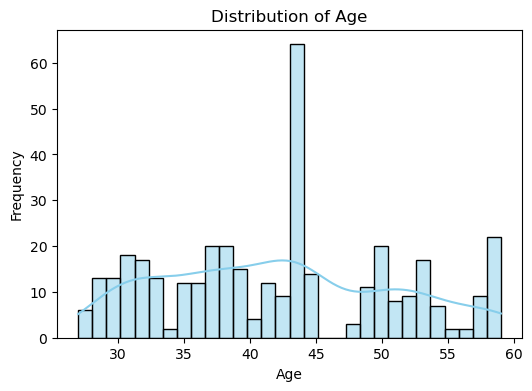

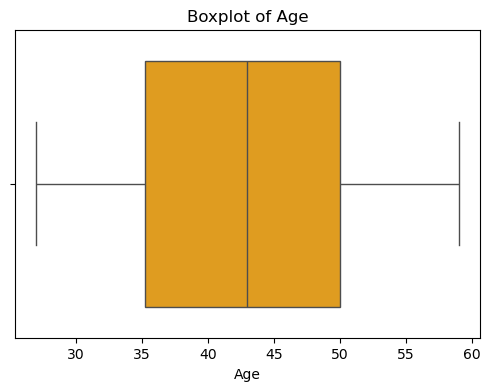

In [7]:
# 6.Univariate analysis -Numerical Features 
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
print("Numeric Columns:", num_cols.tolist())

# Summary statistics
print("\nSummary Statistics for Numeric Features:")
print(df[num_cols].describe())

# Plot histograms for each numeric feature
col=num_cols[1]
plt.figure(figsize=(6, 4))
sns.histplot(df[col], bins=30, kde=True, color='skyblue')
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")
plt.show()

# Plot boxplots for each numeric feature
col=num_cols[1]
plt.figure(figsize=(6, 4))
sns.boxplot(x=df[col], color='orange')
plt.title(f"Boxplot of {col}")
plt.xlabel(col)
plt.show()

Categorical Columns: ['Gender', 'Occupation', 'BMI Category', 'Blood Pressure', 'Sleep Disorder']


C:\Users\Sriram reddy\AppData\Local\Temp\ipykernel_23192\2951537431.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x=col, data=df, kind='count', height=4, aspect=1.5, palette='pastel')


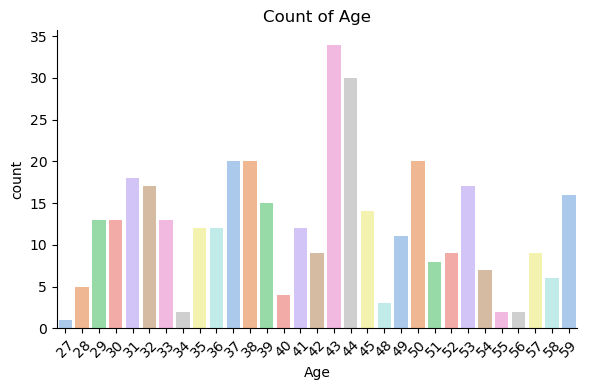

In [9]:
# Univariate Analysis - Categorical Features
# Convert all object columns to category type
df[ df.select_dtypes(include=['object']).columns ] = df.select_dtypes(include=['object']).astype('category')

# Identify categorical columns
cat_cols = df.select_dtypes(include='category').columns
print("Categorical Columns:", cat_cols.tolist())

# Plot count plots for each categorical feature
col=num_cols[1]
sns.catplot(x=col, data=df, kind='count', height=4, aspect=1.5, palette='pastel')
plt.title(f"Count of {col}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\Sriram reddy\AppData\Local\Temp\ipykernel_23192\3671595424.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y='Age', data=df, palette='Set2')


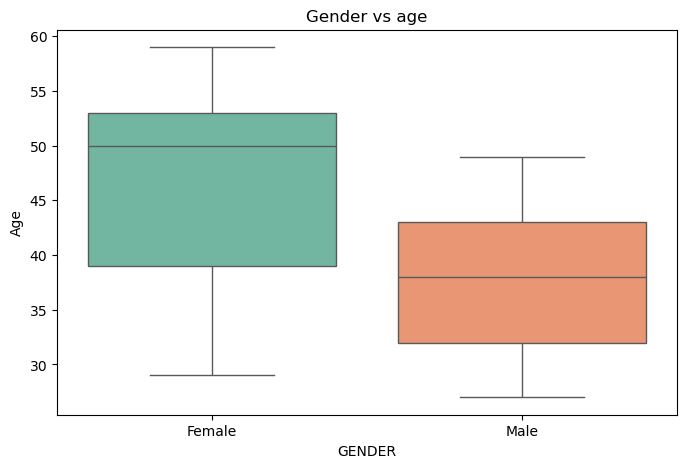

In [10]:
# Bivariate analysis - Numerical vs categorical

plt.figure(figsize=(8,5))
sns.boxplot(x='Gender', y='Age', data=df, palette='Set2')
plt.title("Gender vs age")
plt.xlabel("GENDER")
plt.ylabel("Age")
plt.show()

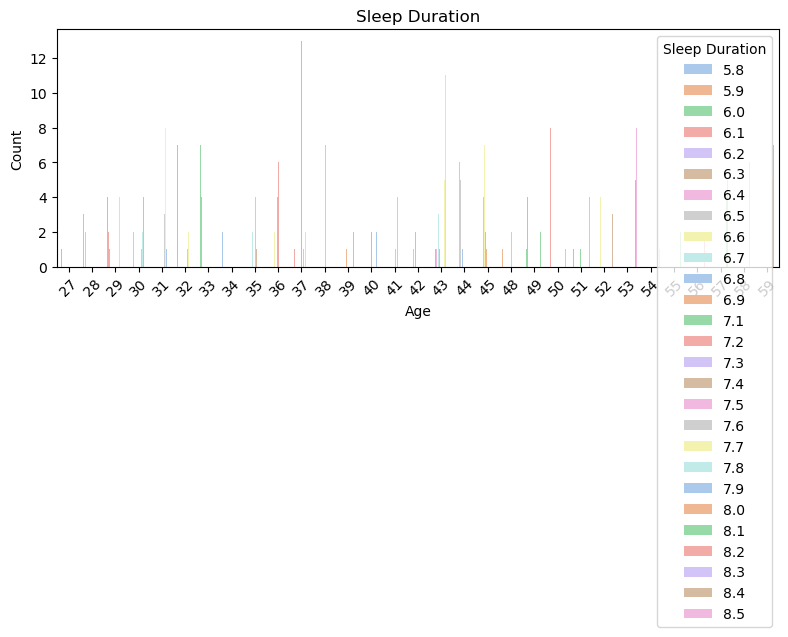

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(x='Age', hue='Sleep Duration', data=df, palette='pastel')
plt.title("Sleep Duration")
plt.xlabel("Age")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Numeric columns used for correlation: ['Person ID', 'Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps']


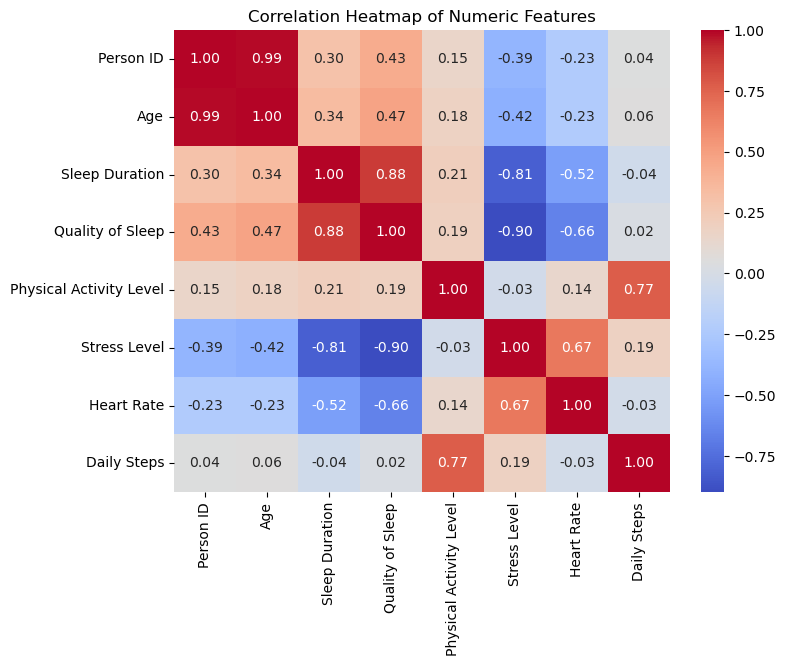

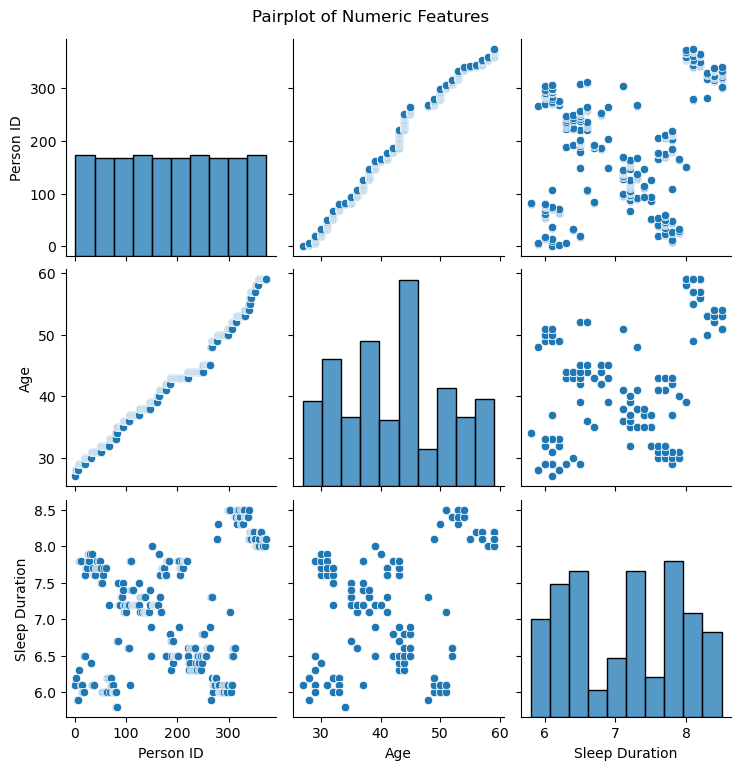

In [16]:
# Select numeric columns for correlation
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Numeric columns used for correlation:", num_cols.tolist())

# Correlation heatmap
corr = df[num_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

# Pairplot for numeric features
sns.pairplot(df[num_cols[:3]])
plt.suptitle("Pairplot of Numeric Features", y=1.02)
plt.show()

### Insights -

1. Person ID is not a meaningful analytical feature — consider dropping it from further modeling or correlation studies.

2. Age and Sleep Duration are weakly correlated (near zero).

Number of outliers in Sales: 0


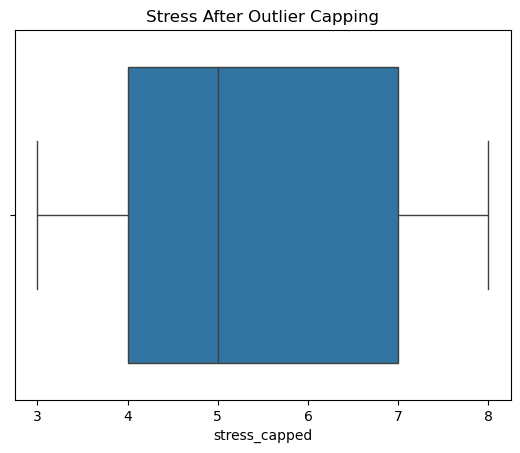

In [18]:
# Outlier Deletion using IQR
Q1 = df['Stress Level'].quantile(0.25)
Q3 = df['Stress Level'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Stress Level'] < lower) | (df['Stress Level'] > upper)]
print("Number of outliers in Sales:", len(outliers))

# Capping outliers
df['stress_capped'] = df['Stress Level'].clip(lower, upper)
sns.boxplot(x=df['stress_capped'])
plt.title("Stress After Outlier Capping")
plt.show()


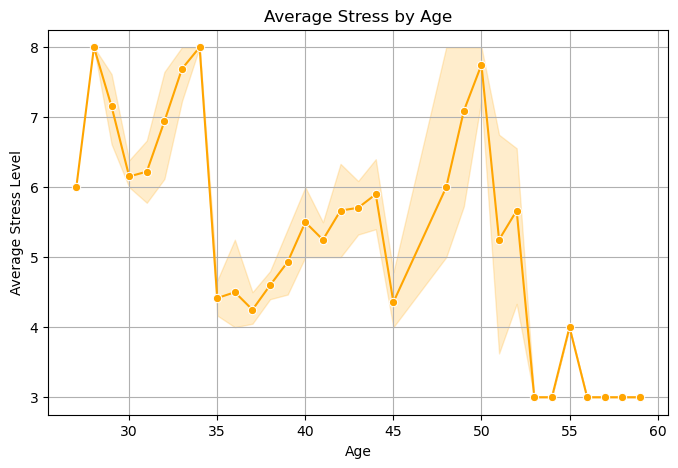

In [25]:
# Plot average age by date
import seaborn as sns
plt.figure(figsize=(8,5))
sns.lineplot(x='Age', y='Stress Level', data=df, marker='o', color='orange')
plt.title("Average Stress by Age")
plt.xlabel("Age")
plt.ylabel("Average Stress Level")
plt.grid(True)
plt.show()

In [28]:
df.to_csv(r"C:\Users\Sriram reddy\Downloads\Sleep_health_and_lifestyle_dataset.csv", index=False)
print("\n✅ Cleaned sleep and health saved as sleep_health_and_lifestyle_dataset_cleaned.csv")


✅ Cleaned sleep and health saved as sleep_health_and_lifestyle_dataset_cleaned.csv


In [30]:
import os
print(os.getcwd())

c:\Users\Sriram reddy\OneDrive\Desktop\tekworks\eda assignment
